# MNIST Neural Network - The Simple Way

## Everything in One Place, Step by Step

---

This notebook teaches you how to build and train a neural network in the **simplest possible way**. No complex functions, no abstractions - just straightforward code you can follow line by line.

**Our Goal:** Recognize handwritten digits (0-9) from images.

---

## Step 1: Import Everything We Need

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.6.0


## Step 2: Choose CPU or GPU

In [2]:
# Use GPU if available, otherwise CPU
# Device konfigurieren
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device: {device}')

Using: cpu


## Step 3: Load the MNIST Dataset

MNIST = 70,000 images of handwritten digits (28×28 pixels, grayscale)

In [3]:
# How to prepare images: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) #
])

# Download and load training data (60,000 images)
train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)

# Download and load test data (10,000 images)
test_data = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Create loaders that give us batches of 64 images at a time
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False) # Bei Test kein shuffle!

print(f"Training images: {len(train_data)}")
print(f"Test images: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.23MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 249kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.10MB/s]

Training images: 60000
Test images: 10000


## Step 4: Look at Some Examples

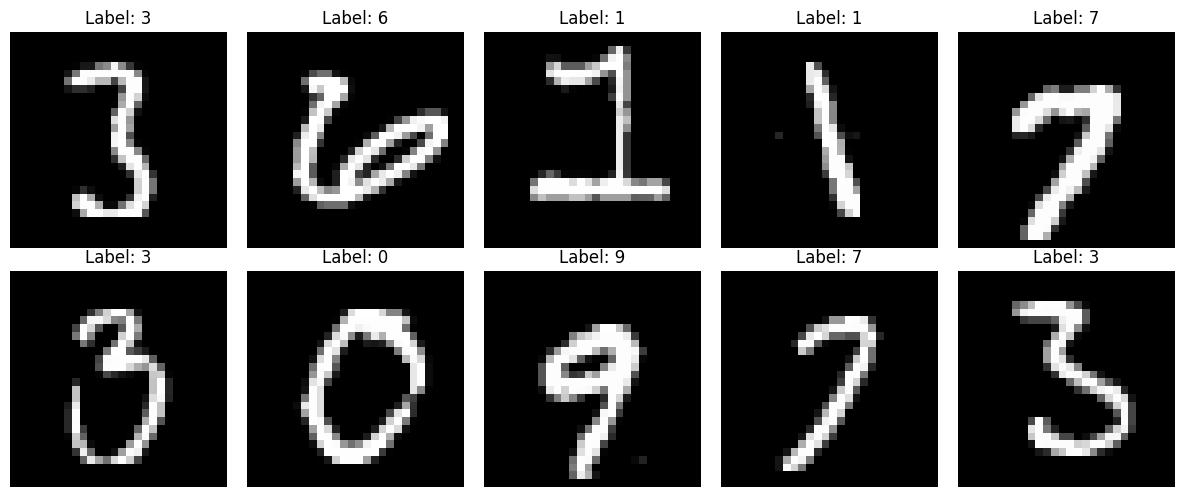

In [4]:
# Get one batch
images, labels = next(iter(train_loader))

# Show 10 examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze() * 0.5 + 0.5  # Undo normalization
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 5: Build the Neural Network

Our network:
```
Input (784 pixels) → Hidden Layer (128 neurons) → Hidden Layer (64 neurons) → Output (10 digits)
```

In [5]:
class NeuralNetwork(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        # Flatten: 28x28 image → 784 numbers
        self.flatten = nn.Flatten()
        
        # Layer 1: 784 inputs → 128 outputs
        self.layer1 = nn.Linear(784, 128)
        
        # Layer 2: 128 inputs → 64 outputs
        self.layer2 = nn.Linear(128, 64)
        
        # Layer 3: 64 inputs → 10 outputs (one per digit)
        self.layer3 = nn.Linear(64, 10)
        
        # Activation function
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.flatten(x)       # Flatten image
        x = self.relu(self.layer1(x))  # Layer 1 + activation
        x = self.relu(self.layer2(x))  # Layer 2 + activation
        x = self.layer3(x)        # Output layer (no activation)
        return x

# Create the model
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


## Step 6: Set Up Training

We need:
1. **Loss function**: Measures how wrong our predictions are
2. **Optimizer**: Updates the weights to reduce the loss

In [6]:
# Loss function: CrossEntropyLoss is standard for classification
loss_function = nn.CrossEntropyLoss()

# Optimizer: Adam is a good default choice
# learning_rate = how big steps we take when updating weights
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Step 7: Train the Network

This is the main training loop. **Read every comment carefully!**

The training process:
1. Get a batch of images
2. Forward pass: compute predictions
3. Compute loss: how wrong are we?
4. Backward pass: compute gradients
5. Update weights: make predictions better

In [7]:
# ========================================
# THE COMPLETE TRAINING LOOP
# ========================================

# How many times to go through all training data
num_epochs = 5

# Store history for plotting later
train_losses = []
test_accuracies = []

print("Starting training...")
print("=" * 60)

# Loop over epochs
for epoch in range(num_epochs):
    
    # ------------------------------------------
    # TRAINING PHASE
    # ------------------------------------------
    
    model.train()  # Tell model we're training (enables dropout, etc.)
    
    total_loss = 0  # Track total loss for this epoch
    
    # Loop over all batches in training data
    for batch_idx, (images, labels) in enumerate(train_loader):
        
        # Move data to device (CPU or GPU)
        images = images.to(device)
        labels = labels.to(device)
        
        # STEP 1: Forward pass - compute predictions
        predictions = model(images)
        
        # STEP 2: Compute loss - how wrong are we?
        loss = loss_function(predictions, labels)
        
        # STEP 3: Zero gradients from previous step
        # (PyTorch accumulates gradients, so we need to reset)
        optimizer.zero_grad()
        
        # STEP 4: Backward pass - compute gradients
        # This calculates: "how should we change each weight?"
        loss.backward()
        
        # STEP 5: Update weights
        # Uses gradients to adjust weights and reduce loss
        optimizer.step()
        
        # Track loss
        total_loss += loss.item()
    
    # Average loss for this epoch
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # ------------------------------------------
    # TESTING PHASE
    # ------------------------------------------
    
    model.eval()  # Tell model we're evaluating (disables dropout, etc.)
    
    correct = 0  # Count correct predictions
    total = 0    # Count total predictions
    
    # Don't compute gradients during testing (faster)
    with torch.no_grad():
        
        # Loop over all batches in test data
        for images, labels in test_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            predictions = model(images)
            
            # Get predicted class (highest score)
            _, predicted_labels = predictions.max(dim=1)
            
            # Count correct predictions
            correct += (predicted_labels == labels).sum().item()
            total += labels.size(0)
    
    # Calculate accuracy
    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    
    # Print progress
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Training Loss: {avg_loss:.4f}")
    print(f"  Test Accuracy: {accuracy:.2f}% ({correct}/{total})")
    print("-" * 40)

print("=" * 60)
print(f"Training complete! Final accuracy: {accuracy:.2f}%")

Starting training...
Epoch 1/5
  Training Loss: 0.3910
  Test Accuracy: 93.46% (9346/10000)
----------------------------------------
Epoch 2/5
  Training Loss: 0.1916
  Test Accuracy: 95.58% (9558/10000)
----------------------------------------
Epoch 3/5
  Training Loss: 0.1399
  Test Accuracy: 96.14% (9614/10000)
----------------------------------------
Epoch 4/5
  Training Loss: 0.1092
  Test Accuracy: 96.86% (9686/10000)
----------------------------------------
Epoch 5/5
  Training Loss: 0.0941
  Test Accuracy: 96.99% (9699/10000)
----------------------------------------
Training complete! Final accuracy: 96.99%


## Step 8: Visualize Training Progress

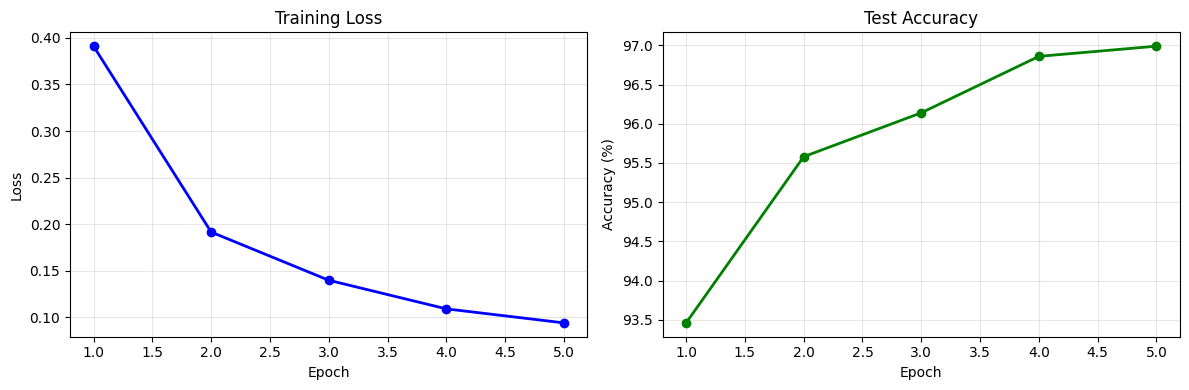

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
ax1.plot(range(1, num_epochs+1), train_losses, 'b-o', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(range(1, num_epochs+1), test_accuracies, 'g-o', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 9: Test on Individual Images

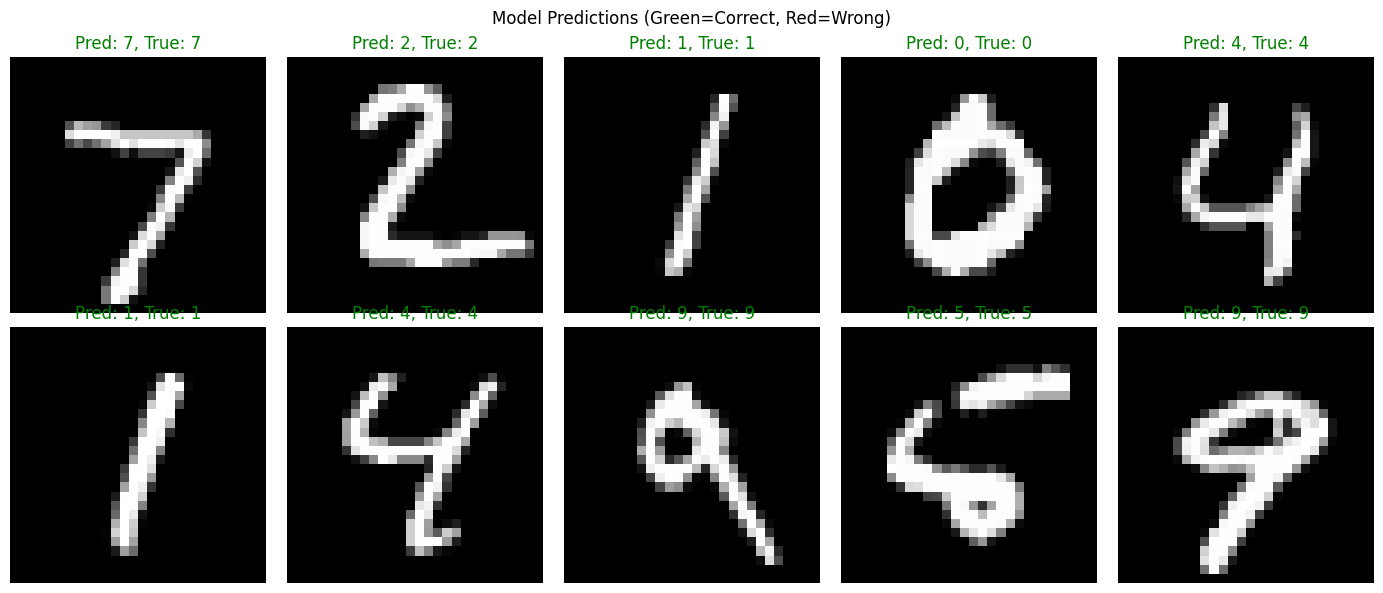

In [9]:
# Get some test images
test_images, test_labels = next(iter(test_loader))

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(test_images.to(device))
    predictions = outputs.argmax(dim=1).cpu()

# Show results
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    img = test_images[i].squeeze() * 0.5 + 0.5
    pred = predictions[i].item()
    true = test_labels[i].item()
    
    ax.imshow(img, cmap='gray')
    
    color = 'green' if pred == true else 'red'
    ax.set_title(f'Pred: {pred}, True: {true}', color=color)
    ax.axis('off')

plt.suptitle('Model Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

---

## Understanding the Training Loop

Let's break down what happens in each step:

### The 5 Steps of Training

```python
# STEP 1: Forward pass
predictions = model(images)
```
**What happens:** Data flows through the network. Each layer transforms the input until we get 10 output values (one per digit).

---

```python
# STEP 2: Compute loss
loss = loss_function(predictions, labels)
```
**What happens:** We compare predictions to actual labels. The loss is a single number that tells us how wrong we are. Lower = better.

---

```python
# STEP 3: Zero gradients
optimizer.zero_grad()
```
**What happens:** PyTorch accumulates gradients by default. We reset them before computing new ones.

---

```python
# STEP 4: Backward pass
loss.backward()
```
**What happens:** PyTorch calculates gradients using the chain rule. For each weight, it computes: "If I increase this weight slightly, how does the loss change?"

---

```python
# STEP 5: Update weights
optimizer.step()
```
**What happens:** Each weight is updated in the direction that reduces the loss:
```
new_weight = old_weight - learning_rate × gradient
```

---

## Key Concepts Explained

### What is `model.train()` vs `model.eval()`?

- **`model.train()`**: Enables training-specific behaviors (like dropout)
- **`model.eval()`**: Disables them for consistent evaluation

### What is `torch.no_grad()`?

During testing, we don't need gradients (no backpropagation). Disabling them:
- Uses less memory
- Runs faster

### What does `predictions.max(dim=1)` return?

For predictions with shape `(batch_size, 10)`:
- Returns the maximum value in each row
- And the index (position) of that maximum
- The index is the predicted digit!

---

## Save Your Model

In [ ]:
# Save
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved!")

# To load later:
# model = NeuralNetwork()
# model.load_state_dict(torch.load('mnist_model.pth'))

---

## Summary

**The essential training loop:**

```python
for epoch in range(num_epochs):
    for images, labels in train_loader:
        
        predictions = model(images)           # Forward
        loss = loss_function(predictions, labels)  # Loss
        
        optimizer.zero_grad()                 # Clear gradients
        loss.backward()                       # Compute gradients
        optimizer.step()                      # Update weights
```

**That's it!** These 5 lines are the core of training any neural network.

---